# Notebook 3.4 -- Activation Functions

The purpose of this practical is to experimnet with different activation functions

In [1]:
using Plots

In [2]:
# Plot the shallow neural network. We'll assume that input is in range [0,1] and output is in [-1,1].
# If the PlotAll flag is set to true, then we'll plot all the intermediate stages as in figure 3.3

function PlotNeural(x, y, Pre₁, Pre₂, Pre₃, Act₁, Act₂, Act₃, WAct₁, WAct₂, WAct₃; PlotAll = false, xData = nothing, yData = nothing)
    if PlotAll 
        p₁₁ = plot(x, Pre₁, color=:red, ylabel="Preactivation", legend=false)
        p₁₂ = plot(x, Pre₂, color=:blue, ylabel="Preactivation", legend=false)
        p₁₃ = plot(x, Pre₃, color=:green, ylabel="Preactivation", legend=false)
        p₂₁ = plot(x, Act₁, color=:red, ylabel="Activation", legend=false)
        p₂₂ = plot(x, Act₂, color=:blue, ylabel="Activation", legend=false)
        p₂₃ = plot(x, Act₃, color=:green, ylabel="Activation", legend=false)
        p₃₁ = plot(x, WAct₁, color=:red, ylabel="Weigted Act", legend=false)
        p₃₂ = plot(x, WAct₂, color=:blue, ylabel="Weigted Act", legend=false)
        p₃₃ = plot(x, WAct₃, color=:green, ylabel="Weigted Act", legend=false)

        plots = [p₁₁, p₁₂, p₁₃, p₂₁, p₂₂, p₂₃, p₃₁, p₃₂, p₃₃]

        for p in plots 
            plot!(p, xlim=(0,1), ylim=(-1,1), aspect_ratio=0.5)
        end
        fig = plot(plots..., layout=(3,3), size=(850, 850))
        display(fig)
    end 
    fig = plot(x, y, xlabel="Input, x", ylabel="Output, y", xlim=(0,1), ylim=(-1,1), aspect_ratio=0.5, legend=false)
    if xData !== nothing 
        scatter!(fig, xData, yData, colot=:magenta, markershape=:circle)
    end
    display(fig)
end

PlotNeural (generic function with 1 method)

In [3]:
# Define a shallow neural network with one input, and three hidden units 

function Shallow_1_1_3(x, ActivationFn, ϕ₀, ϕ₁, ϕ₂, ϕ₃, θ₁₀, θ₁₁, θ₂₀, θ₂₁, θ₃₀,  θ₃₁)
    Pre₁ = θ₁₀ .+ θ₁₁ .* x 
    Pre₂ = θ₂₀ .+ θ₂₁ .* x 
    Pre₃ = θ₃₀ .+ θ₃₁ .* x 

    # pass through the ReLU function to compute the activation as in figure 3.3 d-f 
    Act₁ = ActivationFn(Pre₁)
    Act₂ = ActivationFn(Pre₂)
    Act₃ = ActivationFn(Pre₃)

    WAct₁ = ϕ₁ .* Act₁ 
    WAct₂ = ϕ₂ .* Act₂ 
    WAct₃ = ϕ₃ .* Act₃ 

    y = ϕ₀ .+ WAct₁ .+ WAct₂ .+ WAct₃ 
    return y, Pre₁, Pre₂, Pre₃, Act₁, Act₂, Act₃, WAct₁, WAct₂, WAct₃
end

Shallow_1_1_3 (generic function with 1 method)

In [4]:
# Define the Rectified Linear Unit (ReLU) function 
function ReLU(preactivation)
    activation = max.(0.0, preactivation)
    return activation 
end 

ReLU (generic function with 1 method)

Let's run the network with a ReLU function.

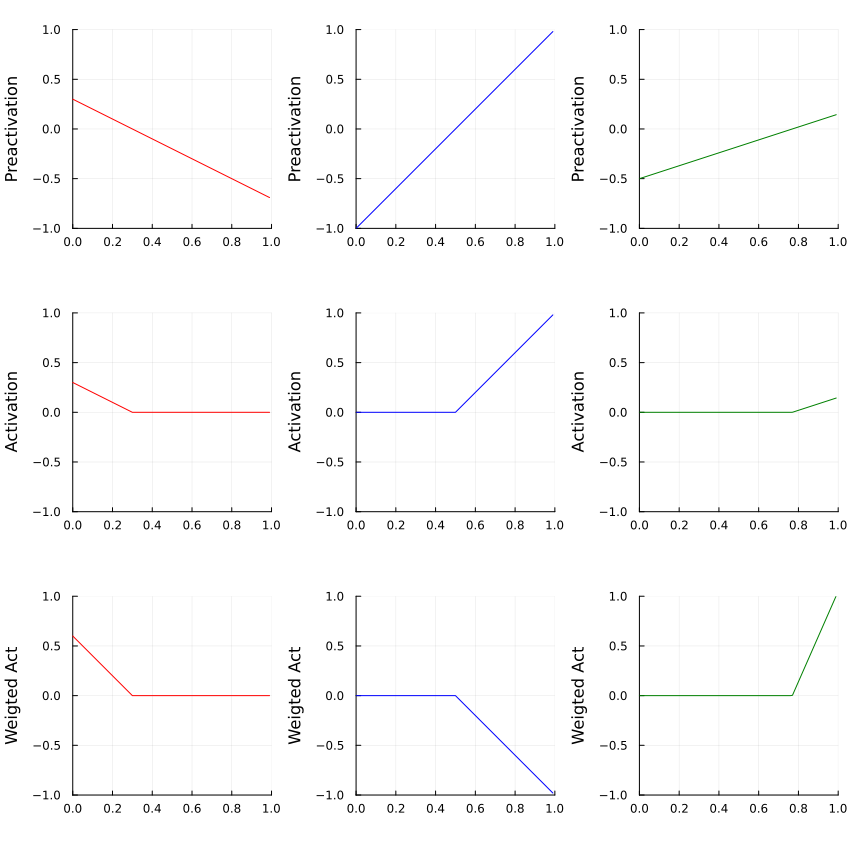

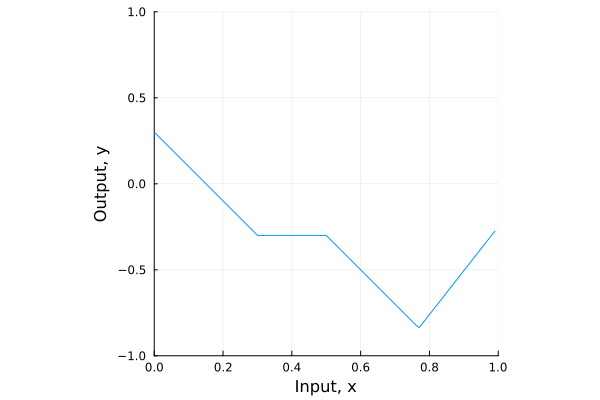

In [5]:
# Let's define some parameters and run the neural network 

θ₁₀ = 0.3; θ₁₁ = -1.0 
θ₂₀ = -1.0; θ₂₁ = 2.0 
θ₃₀ = -0.5; θ₃₁ = 0.65 
ϕ₀ = -0.3; ϕ₁ = 2.0; ϕ₂ = -1.0; ϕ₃ = 7.0 

# Define the range of input values 
x = 0:0.01:0.99 

# we run the neural network fo each of these input values 
y, Pre₁, Pre₂, Pre₃, Act₁, Act₂, Act₃, WAct₁, WAct₂, WAct₃ = Shallow_1_1_3(x, ReLU, ϕ₀, ϕ₁, ϕ₂, ϕ₃, θ₁₀, θ₁₁, θ₂₀, θ₂₁, θ₃₀, θ₃₁)

# And then plot it 
PlotNeural(x, y, Pre₁, Pre₂, Pre₃, Act₁, Act₂, Act₃, WAct₁, WAct₂, WAct₃; PlotAll= true)

# Sigmoid Activation Function 

The ReLU isn't only kind of activation function. For a long time, people used sigmoid functions. A logistic sigmoid function is defined by the equation $$f(z) = \dfrac{1}{1 + exp[-10z]}$$ 
(Note that the factor 10 is not standard, but it allows to plot on the same axes as the ReLU examples)

In [6]:
# Define the Sigmoid function
function sigmoid(preactivation)
    activation = 1.0 ./ (1.0 .+ exp.(-10 * preactivation))
    return activation 
end

sigmoid (generic function with 1 method)

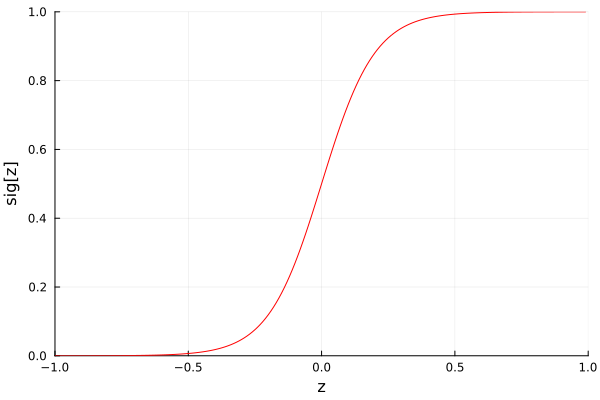

In [7]:
# plot the sigmoid function 
z = -1:0.01:0.99 
sigZ = sigmoid(z) 

fig = plot(z, sigZ, color=:red, xlim=(-1,1), ylim=(0,1), xlabel="z", ylabel="sig[z]", legend=false)
display(fig)

    Let's see what happens when we use this activation function in a neural network 

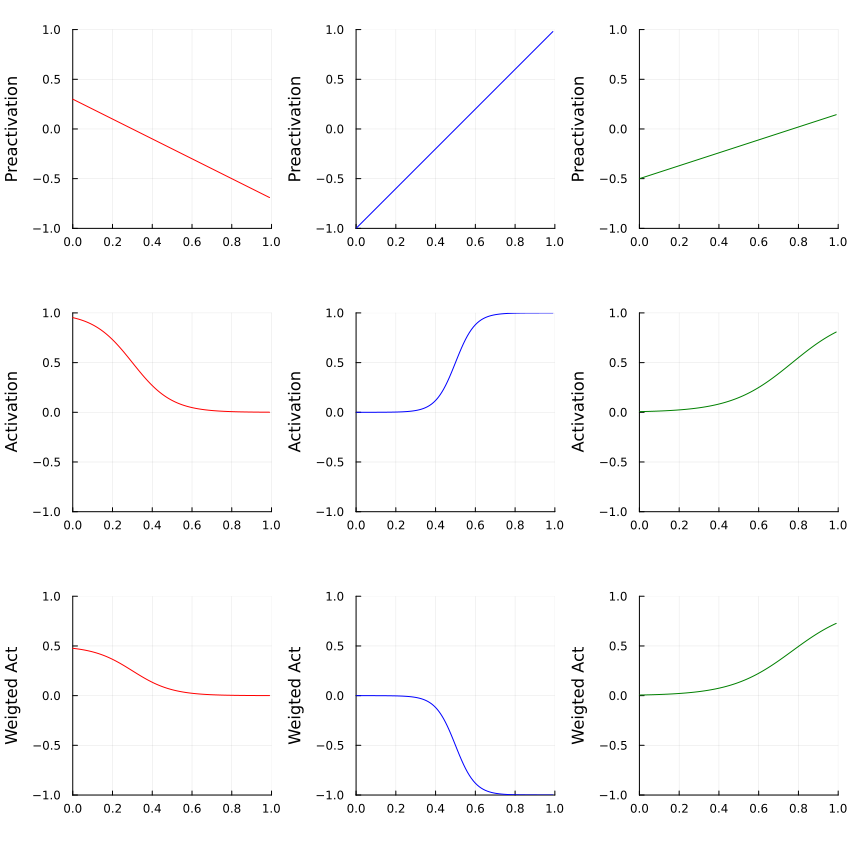

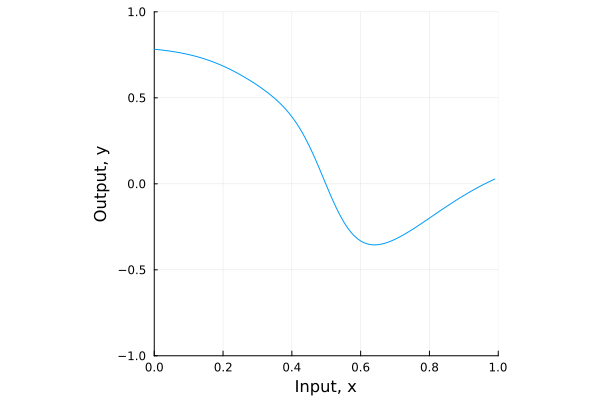

In [8]:
θ₁₀ = 0.3; θ₁₁ = -1.0 
θ₂₀ = -1.0; θ₂₁ = 2.0 
θ₃₀ = -0.5; θ₃₁ = 0.65 
ϕ₀ = 0.3; ϕ₁ = 0.5; ϕ₂ = -1.0; ϕ₃ = 0.9 

# Define a range of input values 
x = 0:0.01:0.99 

# We run the neural network for each of these input values 
y, Pre₁, Pre₂, Pre₃, Act₁, Act₂, Act₃, WAct₁, WAct₂, WAct₃ = Shallow_1_1_3(x, sigmoid, ϕ₀, ϕ₁, ϕ₂, ϕ₃, θ₁₀, θ₁₁, θ₂₀, θ₂₁, θ₃₀, θ₃₁)

#plot it 
PlotNeural(x, y, Pre₁, Pre₂, Pre₃, Act₁, Act₂, Act₃, WAct₁, WAct₂, WAct₃; PlotAll=true)

# Heaviside Activation Function 

The Heaviside activation function defined as $$\text{Heaviside}[z] = \begin{cases}
0 &  :z < 0 \\
1 & : z \geq 0
\end{cases}$$

In [9]:
# Define Heaviside function 

function heaviside(preactivation)
    activation = Float64.(preactivation .>= 0.0)
    return activation 
end

heaviside (generic function with 1 method)

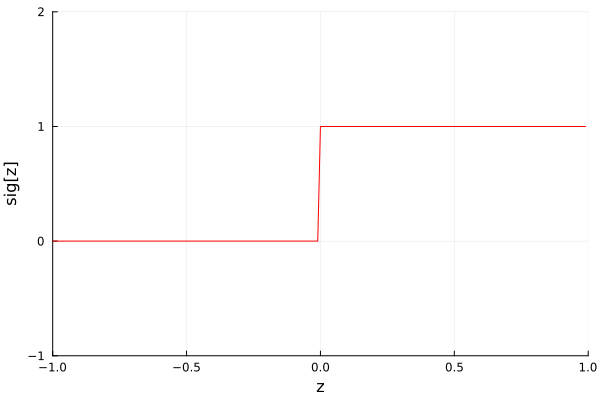

In [10]:
# plot the Heaviside function 
z = -1:0.01:0.99 
sigZ = heaviside(z) 

fig = plot(z, sigZ, color=:red, xlim=(-1,1), ylim=(-1,2), xlabel="z", ylabel="sig[z]", legend=false)
display(fig)

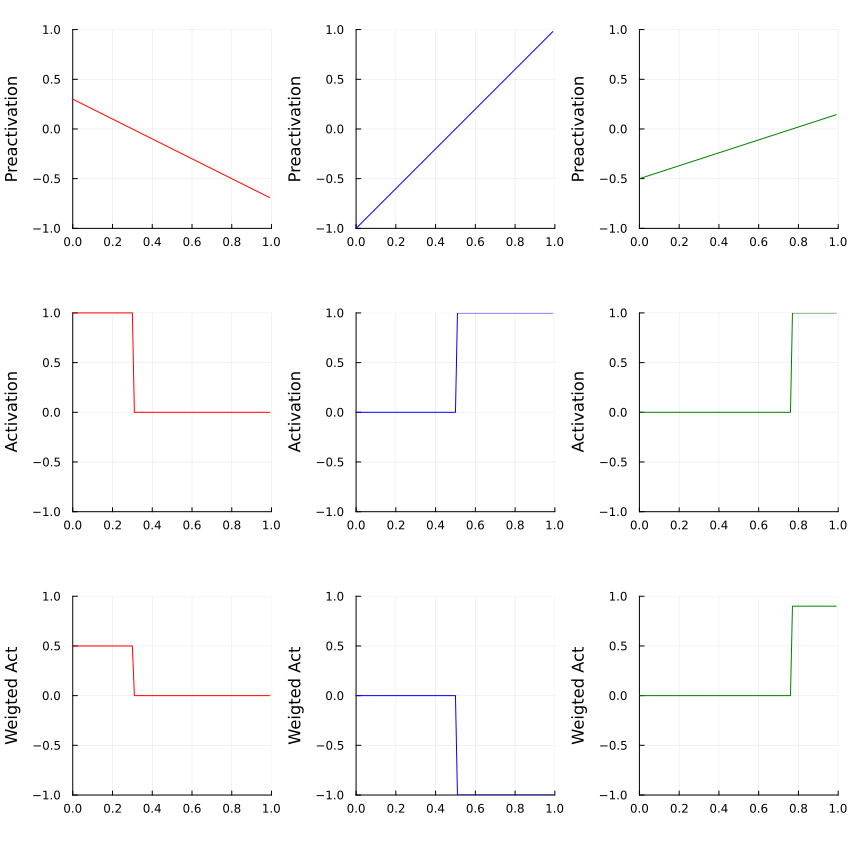

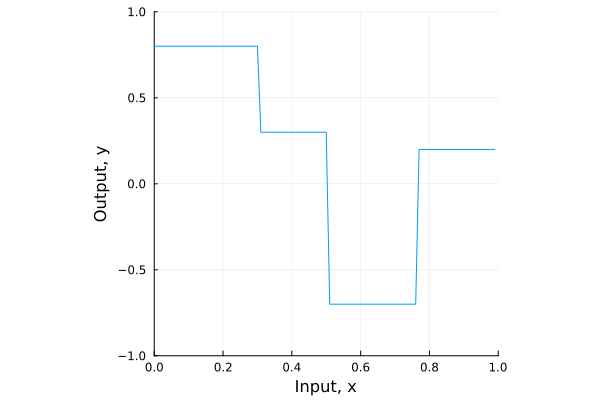

In [11]:
θ₁₀ = 0.3; θ₁₁ = -1.0 
θ₂₀ = -1.0; θ₂₁ = 2.0 
θ₃₀ = -0.5; θ₃₁ = 0.65 
ϕ₀ = 0.3; ϕ₁ = 0.5; ϕ₂ = -1.0; ϕ₃ = 0.9 

# Define a range of input values 
x = 0:0.01:0.99 

# We run the neural network for each of these input values 
y, Pre₁, Pre₂, Pre₃, Act₁, Act₂, Act₃, WAct₁, WAct₂, WAct₃ = Shallow_1_1_3(x, heaviside, ϕ₀, ϕ₁, ϕ₂, ϕ₃, θ₁₀, θ₁₁, θ₂₀, θ₂₁, θ₃₀, θ₃₁)

#plot it 
PlotNeural(x, y, Pre₁, Pre₂, Pre₃, Act₁, Act₂, Act₃, WAct₁, WAct₂, WAct₃; PlotAll=true)

# Linear Activation Function 

Neural networks don't works if the activation function is linear. For example, consider that what would happen if the activation function is $$lin[z] = a + bz. $$

In [12]:
# Define the linear activation function 
function lin(preactivation)
    a = 0.5; b = -0.4
    activation = a .+ b .* preactivation 
    return activation 
end

lin (generic function with 1 method)

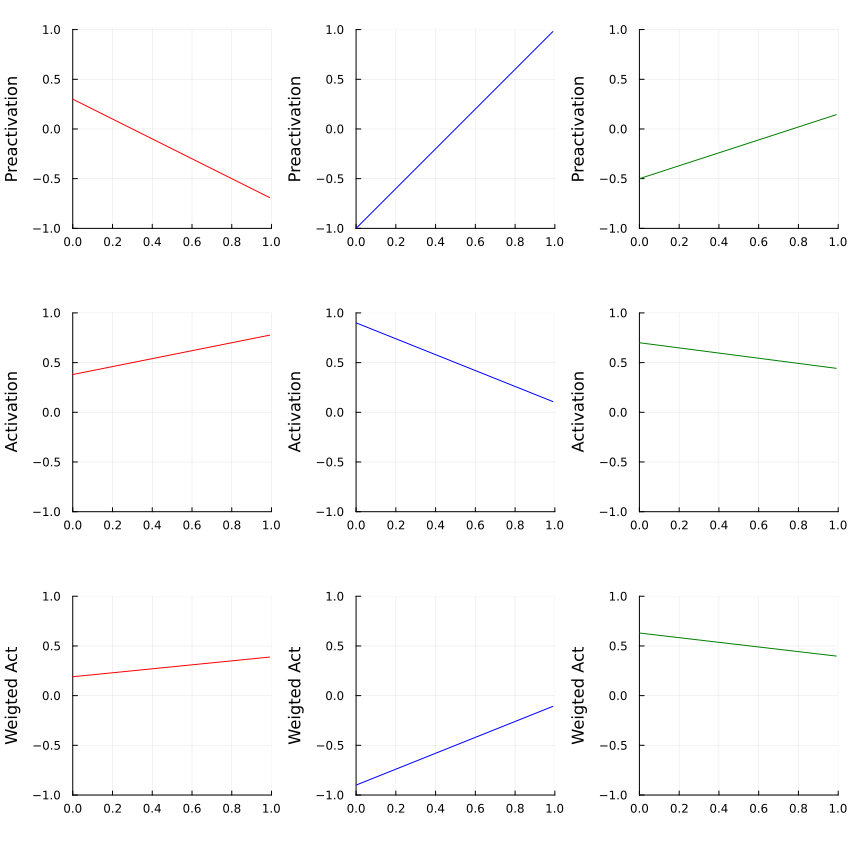

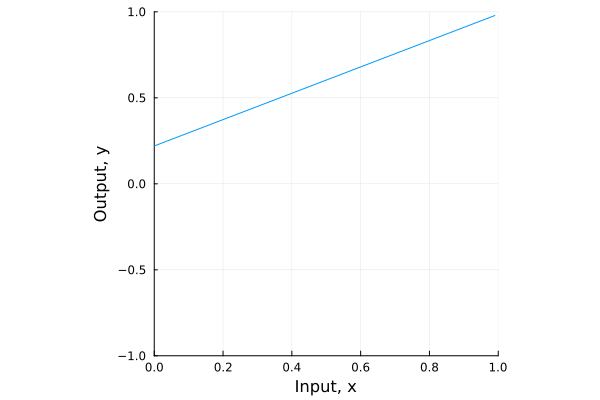

In [13]:
# TODO
# 1. The linear activation function above just returns the input: (0+1*z) = z
# Before running the code Make a prediction about what the ten panels of the drawing will look like
# Now run the code below to see if you were right. What family of functions can this represent?

# 2. What happens if you change the parameters (a,b) to different values?
# Try a=0.5, b=-0.4 Don't forget to run the cell again to update the function

θ₁₀ = 0.3; θ₁₁ = -1.0 
θ₂₀ = -1.0; θ₂₁ = 2.0 
θ₃₀ = -0.5; θ₃₁ = 0.65 
ϕ₀ = 0.3; ϕ₁ = 0.5; ϕ₂ = -1.0; ϕ₃ = 0.9 

# Define a range of input values 
x = 0:0.01:0.99 

# We run the neural network for each of these input values 
y, Pre₁, Pre₂, Pre₃, Act₁, Act₂, Act₃, WAct₁, WAct₂, WAct₃ = Shallow_1_1_3(x, lin, ϕ₀, ϕ₁, ϕ₂, ϕ₃, θ₁₀, θ₁₁, θ₂₀, θ₂₁, θ₃₀, θ₃₁)

#plot it 
PlotNeural(x, y, Pre₁, Pre₂, Pre₃, Act₁, Act₂, Act₃, WAct₁, WAct₂, WAct₃; PlotAll=true)